<a href="https://colab.research.google.com/github/sarabarberiss/breast-cancer-classification/blob/main/Breast_Cancer_Wisconsin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Wisconsin

**Obiettivo.** Confrontare Decision Tree, Bagging, Random Forest e MLP per distinguere campioni benigni e maligni usando nove punteggi citologici.



In [1]:
from pathlib import Path
import json
import platform
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve, log_loss,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import RandomOverSampler


In [2]:
RANDOM_STATE = 42
N_SPLITS = 5
N_TREES = 200
N_JOBS = -1
MAX_EPOCHS = 900
PATIENCE = 30
BATCH_SIZE = 32
TARGET_SENSITIVITY = 0.99
N_BOOTSTRAP = 1000

LOCAL_CSV = None
OUTPUT_DIR = Path("breast_cancer_results")

np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"Benign": "#4C78A8", "Malignant": "#E45756"}


## 2. Dataset e controlli di qualità

Il file [Kaggle](https://www.kaggle.com/datasets/adhyanmaji31/breast-cancer-prediction) del notebook originale contiene 683 osservazioni senza mancanti.

I punteggi sono interi da 1 a 10; Class = 2 indica benigno, Class = 4 maligno.


In [3]:
if LOCAL_CSV is None:
    dataset_path = Path(kagglehub.dataset_download(
        "adhyanmaji31/breast-cancer-prediction/versions/1"
    ))
    csv_path = dataset_path / "Breast Cancer Prediction.csv"
else:
    csv_path = Path(LOCAL_CSV)

csv_sha256 = hashlib.sha256(csv_path.read_bytes()).hexdigest()
df = pd.read_csv(csv_path)
feature_columns = [
    "Clump Thickness", "Uniformity of Cell Size", "Uniformity of Cell Shape",
    "Marginal Adhesion", "Single Epithelial Cell Size", "Bare Nuclei",
    "Bland Chromatin", "Normal Nucleoli", "Mitoses"
]
required_columns = ["Sample code number"] + feature_columns + ["Class"]
assert set(required_columns).issubset(df.columns), "Colonne richieste assenti"

tabular_df = df[required_columns].copy().rename(
    columns={"Sample code number": "SampleID"}
)
for col in feature_columns + ["Class"]:
    tabular_df[col] = pd.to_numeric(tabular_df[col], errors="coerce")
assert tabular_df["SampleID"].notna().all(), "ID mancanti"
assert tabular_df["SampleID"].astype(str).str.strip().ne("").all(), "ID vuoti"
assert tabular_df["Class"].isin([2, 4]).all(), "Classi inattese o mancanti"
assert tabular_df[feature_columns].notna().all().all(), "Feature mancanti/non numeriche"
assert tabular_df[feature_columns].apply(
    lambda s: s.between(1, 10) & (s % 1 == 0)
).all().all(), "Punteggi non interi o fuori dall'intervallo 1–10"

tabular_df["Target"] = tabular_df["Class"].map({2: 0, 4: 1}).astype(int)
tabular_df["Diagnosis"] = tabular_df["Target"].map({0: "Benign", 1: "Malignant"})
tabular_df = tabular_df.drop(columns="Class")
print("Dimensioni del CSV:", df.shape)
print("SHA256:", csv_sha256)
display(tabular_df.head())


100%|██████████| 5.79k/5.79k [00:00<00:00, 9.99MB/s]

Extracting files...
Dimensioni del CSV: (683, 11)
SHA256: 4affe1c9a76a78ff530265581cba7e2779f887ec5add1cdfffaf68ff59f3cee2


,SampleID,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Target,Diagnosis
0,1000025,5,1,1,1,2,1,3,1,1,0,Benign
1,1002945,5,4,4,5,7,10,3,2,1,0,Benign
2,1015425,3,1,1,1,2,2,3,1,1,0,Benign
3,1016277,6,8,8,1,3,4,3,7,1,0,Benign
4,1017023,4,1,1,3,2,1,3,1,1,0,Benign


### ID ripetuti e duplicati


In [4]:
id_counts = tabular_df["SampleID"].value_counts()
classes_per_id = tabular_df.groupby("SampleID")["Target"].nunique()
mixed_ids = classes_per_id[classes_per_id > 1].index
print("ID distinti:", len(id_counts))
print("ID ripetuti:", int((id_counts > 1).sum()))
print("Righe associate a ID ripetuti:", int(id_counts[id_counts > 1].sum()))
print("ID con entrambe le diagnosi:", len(mixed_ids))
if len(mixed_ids):
    display(tabular_df[tabular_df["SampleID"].isin(mixed_ids)]
            .sort_values(["SampleID", "Target"]))

patterns = tabular_df.groupby(feature_columns)["Target"].nunique()
print("Pattern identici con diagnosi diverse:", int((patterns > 1).sum()))

duplicate_columns = ["SampleID"] + feature_columns + ["Target"]
n_removed = int(tabular_df.duplicated(subset=duplicate_columns).sum())
tabular_df = tabular_df.drop_duplicates(subset=duplicate_columns).reset_index(drop=True)
assert not tabular_df.duplicated(subset=duplicate_columns).any()
print("Duplicati rimossi:", n_removed)
print("Osservazioni utilizzate:", len(tabular_df))
display(tabular_df["Diagnosis"].value_counts().to_frame("Count"))

X = tabular_df[feature_columns].copy()
y = tabular_df["Target"].copy()
groups = tabular_df["SampleID"].copy()
assert X.index.equals(y.index) and y.index.equals(groups.index)


ID distinti: 630
ID ripetuti: 45
Righe associate a ID ripetuti: 98
ID con entrambe le diagnosi: 4


,SampleID,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Target,Diagnosis
562,695091,1,1,1,1,2,1,2,1,1,0,Benign
675,695091,5,10,10,5,4,5,4,4,1,1,Malignant
106,1171710,1,1,1,1,2,1,2,3,1,0,Benign
107,1171710,6,5,4,4,3,9,7,8,3,1,Malignant
162,1198641,3,1,1,1,2,1,3,1,1,0,Benign
250,1198641,3,1,1,1,2,1,3,1,1,0,Benign
258,1198641,10,10,6,3,3,10,4,3,2,1,Malignant
628,1299596,2,1,1,1,2,1,1,1,1,0,Benign
452,1299596,6,6,6,5,4,10,7,6,2,1,Malignant


Pattern identici con diagnosi diverse: 0
Duplicati rimossi: 8
Osservazioni utilizzate: 675


,Count
Diagnosis,
Benign,439
Malignant,236


## 3. Suddivisione iniziale del dataset e piano di validazione




In [5]:
holdout_splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)
dev_idx, test_idx = next(holdout_splitter.split(X, y, groups))
X_dev = X.iloc[dev_idx].reset_index(drop=True)
y_dev = y.iloc[dev_idx].reset_index(drop=True)
groups_dev = groups.iloc[dev_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)
assert set(groups_dev).isdisjoint(set(groups_test))

cv_splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)
cv_splits = list(cv_splitter.split(X_dev, y_dev, groups_dev))
inner_splits = []
coverage = np.zeros(len(X_dev), dtype=int)
for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    assert set(groups_dev.iloc[train_idx]).isdisjoint(set(groups_dev.iloc[val_idx]))
    assert y_dev.iloc[train_idx].nunique() == y_dev.iloc[val_idx].nunique() == 2
    coverage[val_idx] += 1
    inner = StratifiedGroupKFold(
        n_splits=5, shuffle=True, random_state=RANDOM_STATE + fold
    )
    inner_train, inner_val = next(inner.split(
        X_dev.iloc[train_idx], y_dev.iloc[train_idx], groups_dev.iloc[train_idx]
    ))
    assert set(groups_dev.iloc[train_idx[inner_train]]).isdisjoint(
        set(groups_dev.iloc[train_idx[inner_val]])
    )
    assert y_dev.iloc[train_idx[inner_train]].nunique() == 2
    assert y_dev.iloc[train_idx[inner_val]].nunique() == 2
    inner_splits.append((inner_train, inner_val))
assert np.all(coverage == 1)

split_summary = pd.DataFrame([
    {"Set": name, "Rows": len(target), "Groups": group.nunique(),
     "Benign": int((target == 0).sum()), "Malignant": int((target == 1).sum()),
     "Malignant %": 100 * target.mean()}
    for name, target, group in [
        ("Development", y_dev, groups_dev), ("Test", y_test, groups_test)
    ]
])
display(split_summary.round(2))
print("Nessun SampleID condiviso; fold verificati.")


,Set,Rows,Groups,Benign,Malignant,Malignant %
0,Development,547,505,355,192,35.10
1,Test,128,125,84,44,34.38


Nessun SampleID condiviso; fold verificati.


<!-- Cella 11 — Markdown -->


### Correlazioni


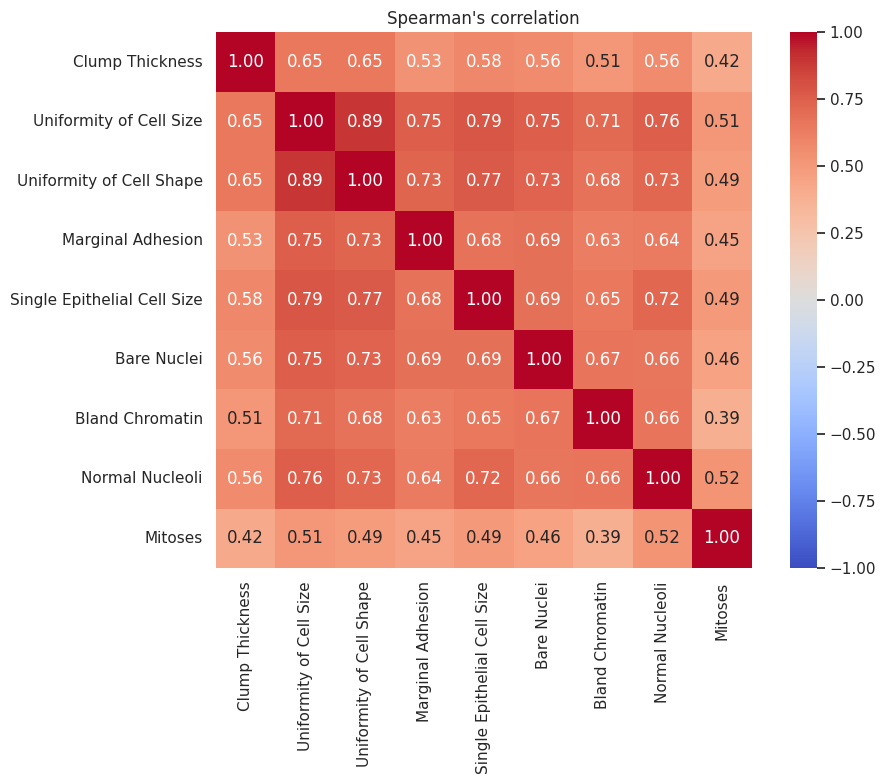

In [6]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    X_dev.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Spearman's correlation")
plt.tight_layout()
plt.show()

## 5. Metriche comuni e scelta della soglia

La funzione di soglia considera tutti i punteggi distinti, inclusa la soglia zero. Sceglie massima specificità tra le soglie che soddisfano il vincolo empirico di sensibilità; a parità privilegia sensibilità e poi soglia maggiore.


In [7]:
def evaluate_probabilities(y_true, probabilities, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    p = np.asarray(probabilities, dtype=float).reshape(-1)
    assert len(y_true) == len(p) and np.isfinite(p).all()
    assert ((p >= 0) & (p <= 1)).all()
    predictions = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "Threshold": float(threshold), "TN": int(tn), "FP": int(fp),
        "FN": int(fn), "TP": int(tp),
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "Specificity": tn / (tn + fp) if tn + fp else np.nan,
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, p) if len(np.unique(y_true)) == 2 else np.nan,
        "AP": average_precision_score(y_true, p) if np.any(y_true == 1) else np.nan,
        "Log-loss": log_loss(y_true, p, labels=[0, 1]),
        "Brier": brier_score_loss(y_true, p)
    }


def select_threshold(y_true, probabilities, target_sensitivity=0.99):
    y_true = np.asarray(y_true, dtype=int)
    p = np.asarray(probabilities, dtype=float).reshape(-1)
    assert 0 < target_sensitivity <= 1
    assert len(np.unique(y_true)) == 2 and np.isfinite(p).all()
    candidates = np.unique(np.r_[0.0, 0.5, 1.0, p])
    rows = []
    for threshold in candidates:
        tn, fp, fn, tp = confusion_matrix(y_true, p >= threshold, labels=[0, 1]).ravel()
        rows.append({"Threshold": threshold, "Sensitivity": tp / (tp + fn),
                     "Specificity": tn / (tn + fp), "FN": fn, "FP": fp})
    table = pd.DataFrame(rows)
    eligible = table[table["Sensitivity"] >= target_sensitivity].sort_values(
        ["Specificity", "Sensitivity", "Threshold"], ascending=[False, False, False]
    )
    return float(eligible.iloc[0]["Threshold"]), table


def evaluate_sklearn_oof(estimator):
    oof = np.full(len(X_dev), np.nan)
    rows, fitted_folds = [], []
    for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        model = clone(estimator)
        model.fit(X_dev.iloc[train_idx], y_dev.iloc[train_idx])
        p = model.predict_proba(X_dev.iloc[val_idx])[:, list(model.classes_).index(1)]
        oof[val_idx] = p
        rows.append({"Fold": fold, **evaluate_probabilities(y_dev.iloc[val_idx], p)})
        fitted_folds.append(model)
    assert np.isfinite(oof).all()
    return {"oof": oof, "folds": pd.DataFrame(rows), "models": fitted_folds}


## 6. Decision Tree

Le barre rappresentano deviazioni standard tra fold, non intervalli di confidenza.


,Depth,Train accuracy,CV accuracy,CV accuracy SD,Train AUC,CV AUC,CV AUC SD
0,1,0.9264,0.9123,0.0137,0.9241,0.9127,0.0206
1,2,0.9589,0.9379,0.0244,0.9685,0.9435,0.0121
2,3,0.9666,0.9415,0.0164,0.9882,0.9564,0.0119
3,4,0.9790,0.9470,0.0215,0.9959,0.9537,0.0366
4,5,0.9867,0.9398,0.0282,0.9988,0.9423,0.0296
5,6,0.9918,0.9398,0.0134,0.9995,0.9357,0.0241
6,8,0.9995,0.9380,0.0192,1.0000,0.9269,0.0269
7,10,1.0000,0.9380,0.0192,1.0000,0.9269,0.0269
8,Unlimited,1.0000,0.9380,0.0192,1.0000,0.9269,0.0269


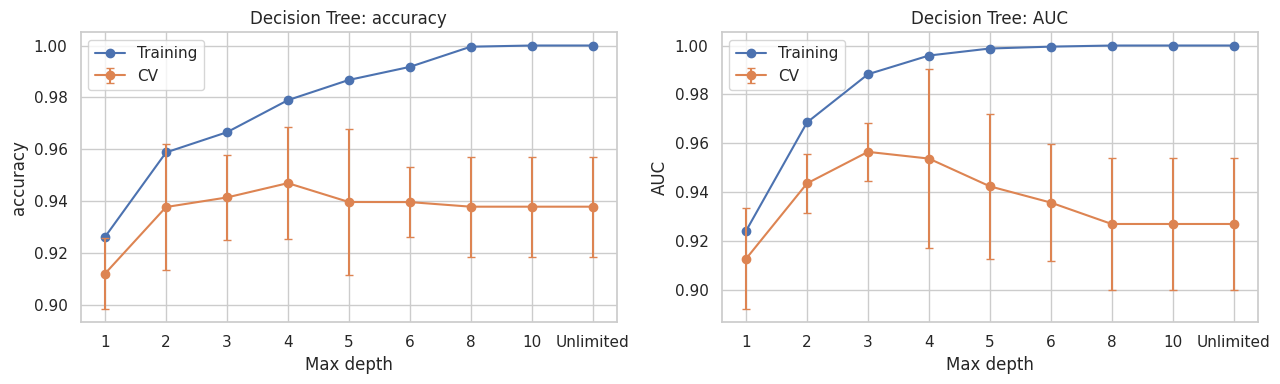

In [8]:
depth_rows = []
for depth in [1, 2, 3, 4, 5, 6, 8, 10, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    scores = cross_validate(
        model, X_dev, y_dev, cv=cv_splits,
        scoring={"accuracy": "accuracy", "auc": "roc_auc"},
        return_train_score=True, n_jobs=N_JOBS
    )
    depth_rows.append({
        "Depth": str(depth) if depth is not None else "Unlimited",
        "Train accuracy": scores["train_accuracy"].mean(),
        "CV accuracy": scores["test_accuracy"].mean(),
        "CV accuracy SD": scores["test_accuracy"].std(ddof=1),
        "Train AUC": scores["train_auc"].mean(),
        "CV AUC": scores["test_auc"].mean(),
        "CV AUC SD": scores["test_auc"].std(ddof=1)
    })
depth_results = pd.DataFrame(depth_rows)
display(depth_results.round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, label in zip(axes, ["accuracy", "AUC"]):
    ax.plot(depth_results["Depth"], depth_results[f"Train {label}"], marker="o", label="Training")
    ax.errorbar(depth_results["Depth"], depth_results[f"CV {label}"],
                yerr=depth_results[f"CV {label} SD"], marker="o", capsize=3, label="CV")
    ax.set(xlabel="Max depth", ylabel=label, title=f"Decision Tree: {label}")
    ax.legend()
plt.tight_layout()
plt.show()


## 7. Logistic regression, albero regolarizzato, Bagging e Random Forest

La regressione logistica è un riferimento lineare con scaling interno alla pipeline.

Bagging combina alberi addestrati su campioni bootstrap. Random Forest aggiunge selezione casuale delle feature candidate a ogni nodo. Entrambi hanno 200 alberi.

Griglie compatte: 36 configurazioni per l'albero, 9 per Bagging, 18 per Random Forest e 3 per regressione logistica.


In [9]:
sklearn_candidates = {
    "Logistic regression": (
        Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(
            max_iter=2000, random_state=RANDOM_STATE))]),
        {"model__C": [0.1, 1.0, 10.0]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"max_depth": [3, 5, None], "min_samples_leaf": [1, 5, 10, 20],
         "ccp_alpha": [0.0, 0.001, 0.01]}
    ),
    "Bagging": (
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=N_TREES, max_samples=1.0, max_features=1.0,
            bootstrap=True, oob_score=False, random_state=RANDOM_STATE, n_jobs=1
        ),
        {"estimator__max_depth": [3, 5, None], "estimator__min_samples_leaf": [1, 5, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=N_TREES, bootstrap=True,
                               oob_score=False, random_state=RANDOM_STATE, n_jobs=1),
        {"max_depth": [3, 5, None], "min_samples_leaf": [1, 5, 10],
         "max_features": ["sqrt", 1.0]}
    )
}

searches, best_sklearn, sklearn_results = {}, {}, {}
for name, (estimator, grid) in sklearn_candidates.items():
    if grid:
        search = GridSearchCV(estimator, grid, scoring="roc_auc", cv=cv_splits,
                              refit=True, n_jobs=N_JOBS, error_score="raise")
        search.fit(X_dev, y_dev)
        searches[name] = search
        best_sklearn[name] = clone(search.best_estimator_)
        print(name, "— parametri:", search.best_params_, "— CV AUC:", round(search.best_score_, 4))
    else:
        best_sklearn[name] = clone(estimator)
    sklearn_results[name] = evaluate_sklearn_oof(best_sklearn[name])

sklearn_summary = pd.DataFrame([
    {"Model": name, "Mean CV AUC": result["folds"]["ROC-AUC"].mean(),
     "CV AUC SD": result["folds"]["ROC-AUC"].std(ddof=1),
     "Mean CV AP": result["folds"]["AP"].mean(),
     "Mean CV accuracy": result["folds"]["Accuracy"].mean(),
     "Mean CV sensitivity": result["folds"]["Sensitivity"].mean(),
     "Mean CV specificity": result["folds"]["Specificity"].mean()}
    for name, result in sklearn_results.items()
]).sort_values("Mean CV AUC", ascending=False)
display(sklearn_summary.round(4))


Logistic regression — parametri: {'model__C': 0.1} — CV AUC: 0.996
Decision Tree — parametri: {'ccp_alpha': 0.0, 'max_depth': None, 'min_samples_leaf': 10} — CV AUC: 0.9872
Bagging — parametri: {'estimator__max_depth': 5, 'estimator__min_samples_leaf': 5} — CV AUC: 0.9924
Random Forest — parametri: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5} — CV AUC: 0.9929


,Model,Mean CV AUC,CV AUC SD,Mean CV AP,Mean CV accuracy,Mean CV sensitivity,Mean CV specificity
0,Logistic regression,0.9960,0.0021,0.9930,0.9672,0.9544,0.9743
3,Random Forest,0.9929,0.0050,0.9863,0.9708,0.9651,0.9743
2,Bagging,0.9924,0.0042,0.9843,0.9690,0.9585,0.9743
1,Decision Tree,0.9872,0.0061,0.9716,0.9416,0.9305,0.9480


### Interpretazione dell'albero

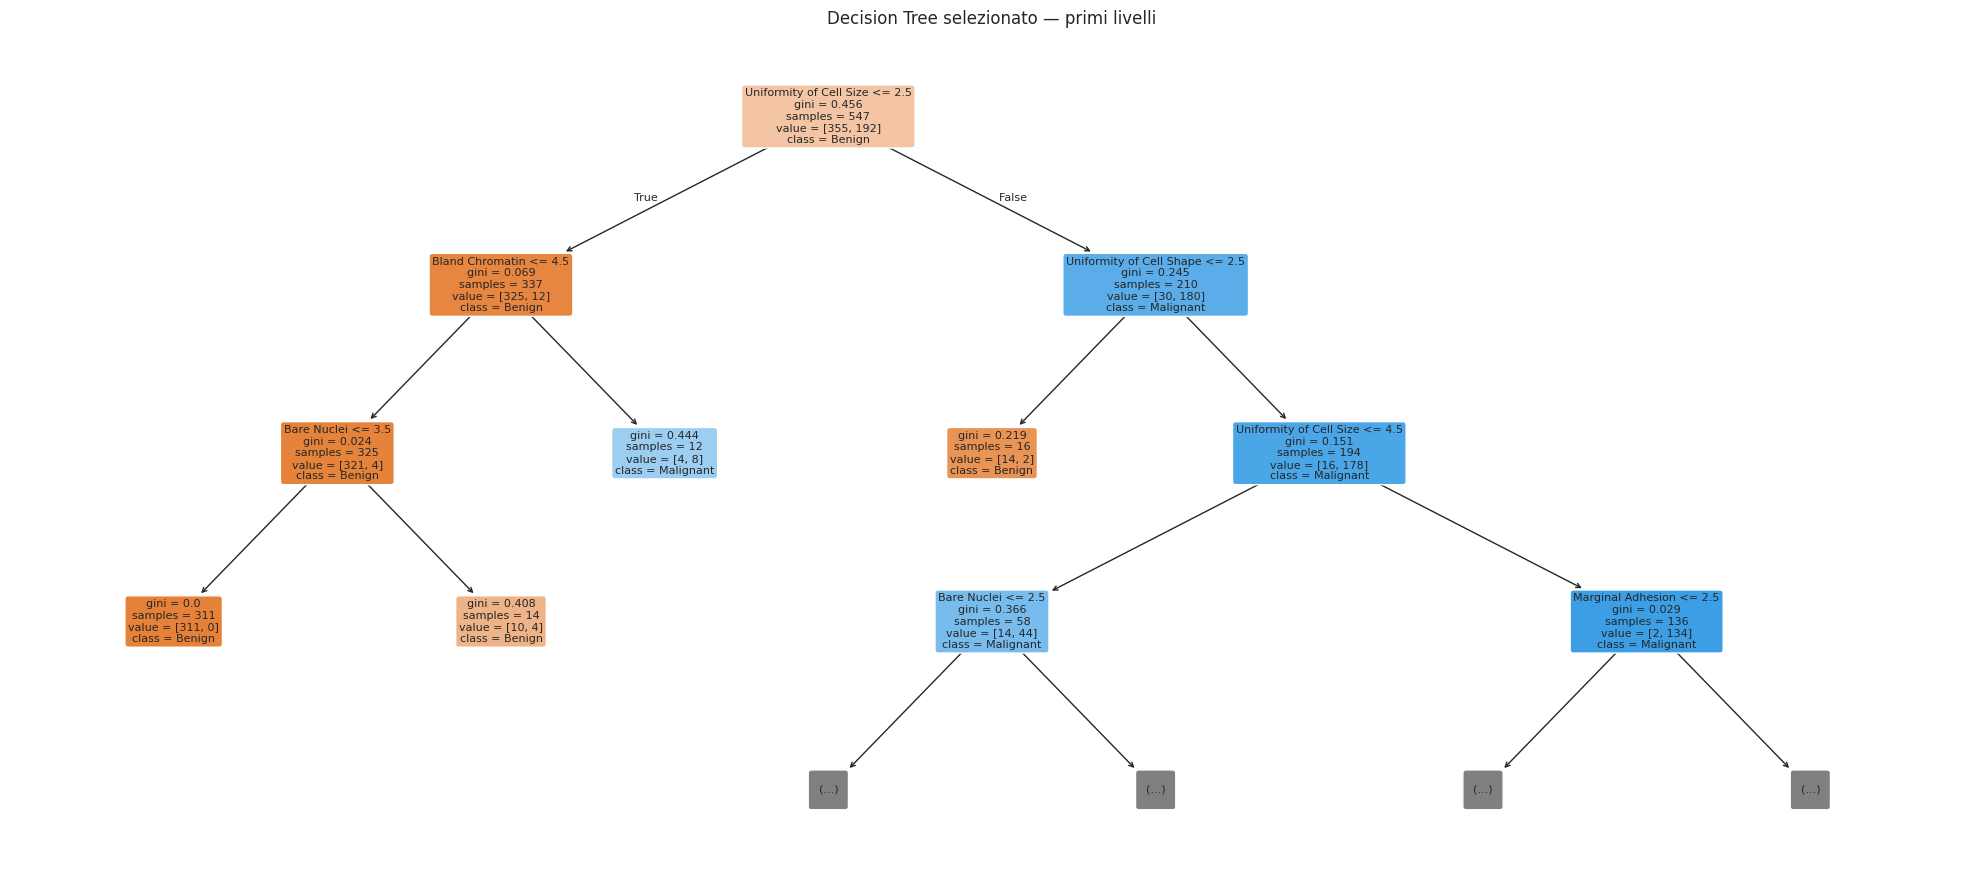

Profondità effettiva: 6
Numero di foglie: 11


In [10]:
interpretable_tree = clone(best_sklearn["Decision Tree"]).fit(X_dev, y_dev)
plt.figure(figsize=(20, 9))
plot_tree(interpretable_tree, feature_names=feature_columns,
          class_names=["Benign", "Malignant"], filled=True,
          rounded=True, max_depth=3, fontsize=8)
plt.title("Decision Tree selezionato — primi livelli")
plt.tight_layout()
plt.show()
print("Profondità effettiva:", interpretable_tree.get_depth())
print("Numero di foglie:", interpretable_tree.get_n_leaves())


### Permutation importance sui fold di validazione

Si misura la diminuzione di AUC quando una feature viene permutata.


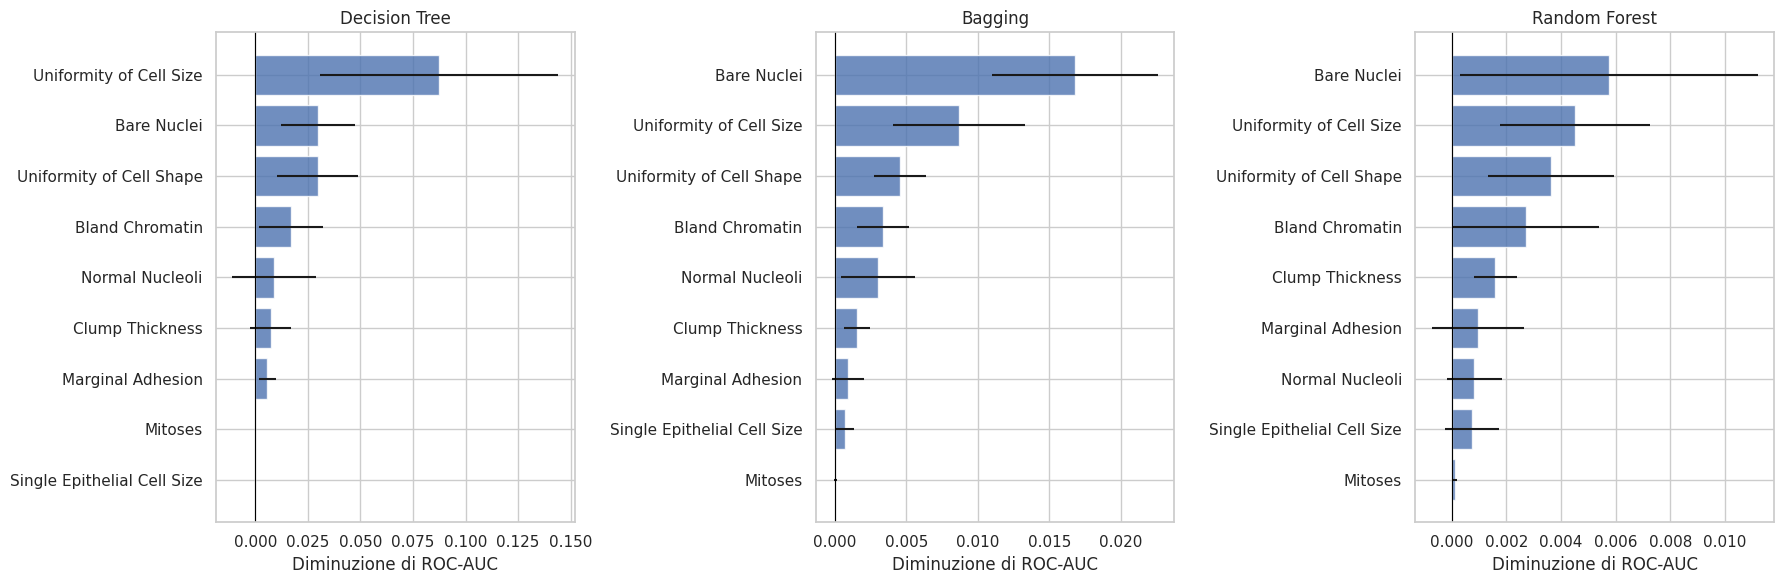

In [11]:
importance_tables = []
for name in ["Decision Tree", "Bagging", "Random Forest"]:
    fold_importances = []
    for (train_idx, val_idx), model in zip(cv_splits, sklearn_results[name]["models"]):
        result = permutation_importance(
            model, X_dev.iloc[val_idx], y_dev.iloc[val_idx], scoring="roc_auc",
            n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS
        )
        fold_importances.append(result.importances_mean)
    values = np.asarray(fold_importances)
    importance_tables.append(pd.DataFrame({
        "Model": name, "Feature": feature_columns,
        "Mean importance": values.mean(axis=0), "Fold SD": values.std(axis=0, ddof=1)
    }))
importance_df = pd.concat(importance_tables, ignore_index=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, name in zip(axes, ["Decision Tree", "Bagging", "Random Forest"]):
    table = importance_df[importance_df["Model"] == name].sort_values("Mean importance")
    ax.barh(table["Feature"], table["Mean importance"], xerr=table["Fold SD"], alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title=name, xlabel="Diminuzione di ROC-AUC")
plt.tight_layout()
plt.show()


### Selezione ricorsiva delle feature


In [12]:
F_MIN = 0.995

fs_estimator = RandomForestClassifier(
    n_estimators=N_TREES,
    max_depth=5,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=1
)

fs_rows = []
fs_selected_sets = []

for fold, ((train_idx, val_idx), (inner_train, inner_val)) in enumerate(
    zip(cv_splits, inner_splits),
    start=1
):
    # Gli indici interni sono relativi al training del fold esterno.
    selection_train_idx = train_idx[inner_train]
    selection_val_idx = train_idx[inner_val]

    X_selection_train = X_dev.iloc[selection_train_idx]
    y_selection_train = y_dev.iloc[selection_train_idx]

    X_selection_val = X_dev.iloc[selection_val_idx]
    y_selection_val = y_dev.iloc[selection_val_idx]

    selected_features = list(feature_columns)

    current_model = clone(fs_estimator)
    current_model.fit(
        X_selection_train[selected_features],
        y_selection_train
    )

    initial_auc = roc_auc_score(
        y_selection_val,
        current_model.predict_proba(
            X_selection_val[selected_features]
        )[:, 1]
    )

    minimum_auc = initial_auc * F_MIN

    while len(selected_features) > 1:
        # L'importanza viene ricalcolata dopo ogni eliminazione.
        permutation = permutation_importance(
            current_model,
            X_selection_val[selected_features],
            y_selection_val,
            scoring="roc_auc",
            n_repeats=10,
            random_state=RANDOM_STATE + fold,
            n_jobs=N_JOBS
        )

        least_important_idx = int(
            np.argmin(permutation.importances_mean)
        )
        feature_to_remove = selected_features[least_important_idx]

        candidate_features = [
            feature for feature in selected_features
            if feature != feature_to_remove
        ]

        candidate_model = clone(fs_estimator)
        candidate_model.fit(
            X_selection_train[candidate_features],
            y_selection_train
        )

        candidate_auc = roc_auc_score(
            y_selection_val,
            candidate_model.predict_proba(
                X_selection_val[candidate_features]
            )[:, 1]
        )

        # Se la riduzione non è accettabile, manteniamo l'ultimo sottoinsieme accettato e terminiamo.
        if candidate_auc < minimum_auc:
            break

        selected_features = candidate_features
        current_model = candidate_model


    outer_auc = {}

    for label, features in [
        ("Full", feature_columns),
        ("Selected", selected_features)
    ]:
        outer_model = clone(fs_estimator)
        outer_model.fit(
            X_dev.iloc[train_idx][features],
            y_dev.iloc[train_idx]
        )

        probabilities = outer_model.predict_proba(
            X_dev.iloc[val_idx][features]
        )[:, 1]

        outer_auc[label] = roc_auc_score(
            y_dev.iloc[val_idx],
            probabilities
        )

    fs_selected_sets.append(selected_features.copy())

    fs_rows.append({
        "Fold": fold,
        "Number of selected features": len(selected_features),
        "Full AUC": outer_auc["Full"],
        "Selected AUC": outer_auc["Selected"],
        "AUC difference": outer_auc["Selected"] - outer_auc["Full"],
        "Selected features": ", ".join(selected_features)
    })

fs_results = pd.DataFrame(fs_rows)

display(fs_results.round(4))

fs_summary = pd.DataFrame({
    "Mean outer-fold AUC": fs_results[
        ["Full AUC", "Selected AUC"]
    ].mean(),
    "Outer-fold AUC SD": fs_results[
        ["Full AUC", "Selected AUC"]
    ].std(ddof=1)
})

display(fs_summary.round(4))

selection_frequency = pd.Series(
    {
        feature: sum(
            feature in selected
            for selected in fs_selected_sets
        )
        for feature in feature_columns
    },
    name="Number of folds retaining the feature"
).sort_values(ascending=False)

display(selection_frequency.to_frame())

,Fold,Number of selected features,Full AUC,Selected AUC,AUC difference,Selected features
0,1,3,0.9972,0.9972,0.0000,"Uniformity of Cell Size, Uniformity of Cell Sh..."
1,2,1,0.9938,0.9709,-0.0229,Uniformity of Cell Shape
2,3,3,0.9926,0.9890,-0.0035,"Uniformity of Cell Size, Uniformity of Cell Sh..."
3,4,2,0.9846,0.9796,-0.0050,"Uniformity of Cell Size, Bare Nuclei"
4,5,2,0.9964,0.9863,-0.0100,"Uniformity of Cell Size, Bare Nuclei"


,Mean outer-fold AUC,Outer-fold AUC SD
Full AUC,0.9929,0.0050
Selected AUC,0.9846,0.0099


,Number of folds retaining the feature
Uniformity of Cell Size,4
Bare Nuclei,4
Uniformity of Cell Shape,3
Clump Thickness,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0


## 8. MLP: una sola funzione e protocollo comune

La MLP combina gli ingressi con strati Dense/ReLU e restituisce uno score sigmoid.

Si usa Dropout dopo **ogni** strato nascosto e regolarizzazione L2.

La loss di training è binary cross-entropy + L2.


In [13]:
def build_mlp(n_features, hidden_units=(16, 8), dropout_rate=0.2,
              l2_strength=1e-4, learning_rate=1e-3, seed=RANDOM_STATE):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model = keras.Sequential([layers.Input(shape=(n_features,))])
    for units in hidden_units:
        model.add(layers.Dense(units, activation="relu",
                               kernel_regularizer=regularizers.l2(l2_strength)))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")]
    )
    return model


def evaluate_mlp_oof(config, features, oversampling=False):
    oof = np.full(len(X_dev), np.nan)
    rows, histories, epochs_selected = [], [], []
    for fold, ((train_idx, val_idx), (inner_train, inner_val)) in enumerate(
        zip(cv_splits, inner_splits), start=1
    ):
        seed = RANDOM_STATE + fold
        X_outer = X_dev.iloc[train_idx][features]
        y_outer = y_dev.iloc[train_idx].to_numpy()
        scaler_inner = StandardScaler()
        Xi = scaler_inner.fit_transform(X_outer.iloc[inner_train]).astype("float32")
        Xv = scaler_inner.transform(X_outer.iloc[inner_val]).astype("float32")
        yi = y_outer[inner_train]
        if oversampling:
            Xi, yi = RandomOverSampler(random_state=seed).fit_resample(Xi, yi)
        early = callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                         min_delta=0.0, restore_best_weights=True, mode="min")
        model = build_mlp(len(features), **config, seed=seed)
        history = model.fit(Xi, yi, validation_data=(Xv, y_outer[inner_val]),
                            epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                            callbacks=[early, callbacks.TerminateOnNaN()], verbose=0)
        loss_values = np.asarray(history.history["val_loss"])
        assert np.isfinite(loss_values).all(), "Loss MLP non finita"
        best_epoch = int(loss_values.argmin() + 1)
        if len(loss_values) == MAX_EPOCHS:
            warnings.warn(f"Fold {fold}: raggiunto MAX_EPOCHS; controllare le curve sullo sviluppo.")
        histories.append(history.history)
        epochs_selected.append(best_epoch)

        scaler_outer = StandardScaler()
        Xt = scaler_outer.fit_transform(X_outer).astype("float32")
        Xe = scaler_outer.transform(X_dev.iloc[val_idx][features]).astype("float32")
        yt = y_outer
        if oversampling:
            Xt, yt = RandomOverSampler(random_state=seed).fit_resample(Xt, yt)
        refitted = build_mlp(len(features), **config, seed=seed)
        refitted.fit(Xt, yt, epochs=best_epoch, batch_size=BATCH_SIZE, verbose=0,
                     callbacks=[callbacks.TerminateOnNaN()])
        p = refitted.predict(Xe, verbose=0).ravel()
        assert np.isfinite(p).all()
        oof[val_idx] = p
        row = {"Fold": fold, "Best epoch": best_epoch,
               **evaluate_probabilities(y_dev.iloc[val_idx], p)}
        rows.append(row)
        print(f"  Fold {fold}: AUC={row['ROC-AUC']:.4f}, epoche={best_epoch}")
    assert np.isfinite(oof).all()
    return {"oof": oof, "folds": pd.DataFrame(rows),
            "histories": histories, "epochs": epochs_selected}


### Confronto di architetture sul set completo



In [14]:
mlp_configs = {
    "Small": {"hidden_units": (8,), "dropout_rate": 0.1,
              "l2_strength": 1e-4, "learning_rate": 1e-3},
    "Baseline": {"hidden_units": (16, 8), "dropout_rate": 0.2,
                 "l2_strength": 1e-4, "learning_rate": 1e-3},
    "Lower learning rate": {"hidden_units": (16, 8), "dropout_rate": 0.2,
                            "l2_strength": 1e-4, "learning_rate": 3e-4}
}
mlp_architecture_results = {}
for name, config in mlp_configs.items():
    print("MLP:", name)
    mlp_architecture_results[name] = evaluate_mlp_oof(config, feature_columns)

mlp_architecture_summary = pd.DataFrame([
    {"Configuration": name, "Mean CV AUC": result["folds"]["ROC-AUC"].mean(),
     "CV AUC SD": result["folds"]["ROC-AUC"].std(ddof=1),
     "Mean CV log-loss": result["folds"]["Log-loss"].mean(),
     "Median epochs": int(np.median(result["epochs"]))}
    for name, result in mlp_architecture_results.items()
]).sort_values(["Mean CV AUC", "Mean CV log-loss"], ascending=[False, True])
display(mlp_architecture_summary.round(4))
selected_config_name = mlp_architecture_summary.iloc[0]["Configuration"]
selected_mlp_config = mlp_configs[selected_config_name].copy()
original_mlp_result = mlp_architecture_results[selected_config_name]
print("Configurazione selezionata sullo sviluppo:", selected_config_name)


MLP: Small
  Fold 1: AUC=0.9968, epoche=116
  Fold 2: AUC=0.9894, epoche=783


  Fold 3: AUC=0.9977, epoche=70
  Fold 4: AUC=0.9906, epoche=182
  Fold 5: AUC=0.9945, epoche=223
MLP: Baseline
  Fold 1: AUC=0.9961, epoche=108
  Fold 2: AUC=0.9881, epoche=205
  Fold 3: AUC=0.9973, epoche=40
  Fold 4: AUC=0.9893, epoche=76
  Fold 5: AUC=0.9953, epoche=125
MLP: Lower learning rate
  Fold 1: AUC=0.9958, epoche=226
  Fold 2: AUC=0.9894, epoche=478
  Fold 3: AUC=0.9973, epoche=129
  Fold 4: AUC=0.9896, epoche=253
  Fold 5: AUC=0.9956, epoche=439


,Configuration,Mean CV AUC,CV AUC SD,Mean CV log-loss,Median epochs
0,Small,0.9938,0.0037,0.1198,182
2,Lower learning rate,0.9935,0.0037,0.1019,253
1,Baseline,0.9932,0.0042,0.1096,108


Configurazione selezionata sullo sviluppo: Small


### Curve di apprendimento e analisi secondaria full/reduced



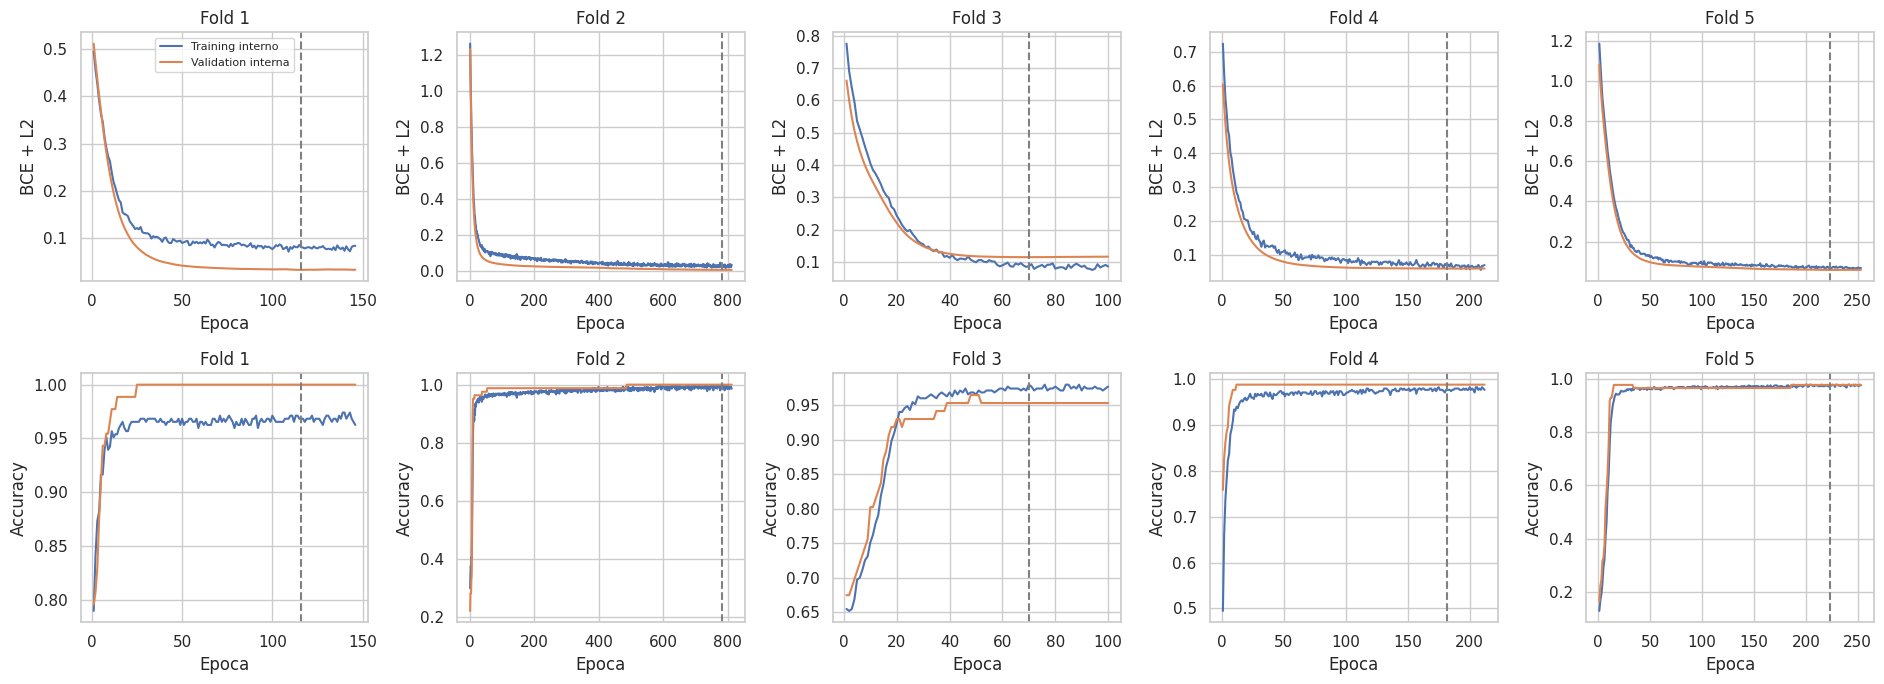

  Fold 1: AUC=0.9975, epoche=116
  Fold 2: AUC=0.9925, epoche=324
  Fold 3: AUC=0.9949, epoche=69
  Fold 4: AUC=0.9916, epoche=109
  Fold 5: AUC=0.9975, epoche=298


,Feature set,Features,Mean CV AUC,CV AUC SD
0,Full (principale),9,0.9938,0.0037
1,Reduced (secondario),7,0.9948,0.0027


In [15]:
fig, axes = plt.subplots(2, N_SPLITS, figsize=(19, 7))
for j, history in enumerate(original_mlp_result["histories"]):
    epoch_axis = np.arange(1, len(history["loss"]) + 1)
    best = original_mlp_result["epochs"][j]
    for row, metric in enumerate(["loss", "accuracy"]):
        axes[row, j].plot(epoch_axis, history[metric], label="Training interno")
        axes[row, j].plot(epoch_axis, history[f"val_{metric}"], label="Validation interna")
        axes[row, j].axvline(best, color="gray", linestyle="--")
        axes[row, j].set(title=f"Fold {j+1}", xlabel="Epoca",
                         ylabel="BCE + L2" if metric == "loss" else "Accuracy")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

reduced_features = [f for f in feature_columns if f not in ["Mitoses", "Single Epithelial Cell Size"]]
reduced_mlp_result = evaluate_mlp_oof(selected_mlp_config, reduced_features)
feature_comparison = pd.DataFrame([
    {"Feature set": name, "Features": count,
     "Mean CV AUC": result["folds"]["ROC-AUC"].mean(),
     "CV AUC SD": result["folds"]["ROC-AUC"].std(ddof=1)}
    for name, count, result in [
        ("Full (principale)", 9, original_mlp_result),
        ("Reduced (secondario)", 7, reduced_mlp_result)
    ]
])
display(feature_comparison.round(4))


### Oversampling: confronto sul solo training


In [16]:
oversampled_mlp_result = evaluate_mlp_oof(
    selected_mlp_config, feature_columns, oversampling=True
)
sampling_results = {"Original": original_mlp_result, "Oversampling": oversampled_mlp_result}
sampling_summary = pd.DataFrame([
    {"Sampling": name, "Mean CV AUC": result["folds"]["ROC-AUC"].mean(),
     "CV AUC SD": result["folds"]["ROC-AUC"].std(ddof=1),
     "Mean CV AP": result["folds"]["AP"].mean(),
     "Mean CV log-loss": result["folds"]["Log-loss"].mean()}
    for name, result in sampling_results.items()
]).sort_values(["Mean CV AUC", "Mean CV log-loss"], ascending=[False, True])
display(sampling_summary.round(4))
selected_sampling = sampling_summary.iloc[0]["Sampling"]
use_oversampling_final = selected_sampling == "Oversampling"
selected_mlp_result = sampling_results[selected_sampling]
final_epochs = int(np.median(selected_mlp_result["epochs"]))
print("Sampling selezionato:", selected_sampling)
print("Epoche per il refit finale:", final_epochs)


  Fold 1: AUC=0.9972, epoche=148
  Fold 2: AUC=0.9885, epoche=585
  Fold 3: AUC=0.9977, epoche=48
  Fold 4: AUC=0.9916, epoche=123
  Fold 5: AUC=0.9942, epoche=237


,Sampling,Mean CV AUC,CV AUC SD,Mean CV AP,Mean CV log-loss
1,Oversampling,0.9938,0.0038,0.9866,0.1156
0,Original,0.9938,0.0037,0.9864,0.1198


Sampling selezionato: Oversampling
Epoche per il refit finale: 148


## 9. Confronto di sviluppo e soglie bloccate prima del test


In [17]:

all_development_results = {**sklearn_results, "MLP": selected_mlp_result}
development_summary = pd.DataFrame([
    {"Model": name, "Mean CV AUC": result["folds"]["ROC-AUC"].mean(),
     "CV AUC SD": result["folds"]["ROC-AUC"].std(ddof=1),
     "Mean CV AP": result["folds"]["AP"].mean(),
     "Mean CV log-loss": result["folds"]["Log-loss"].mean(),
     "Pooled OOF AUC": roc_auc_score(y_dev, result["oof"])}
    for name, result in all_development_results.items()
]).sort_values(["Mean CV AUC", "Mean CV log-loss"], ascending=[False, True])
display(development_summary.round(4))
selected_family = development_summary.query("Model != 'Dummy'").iloc[0]["Model"]

selected_thresholds, threshold_tables, threshold_rows = {}, {}, []
for name, result in all_development_results.items():
    if name == "Dummy":
        selected_thresholds[name] = 0.5
        continue
    threshold, table = select_threshold(y_dev, result["oof"], TARGET_SENSITIVITY)
    selected_thresholds[name] = threshold
    threshold_tables[name] = table
    threshold_rows.append({"Model": name, **evaluate_probabilities(y_dev, result["oof"], threshold)})
threshold_summary = pd.DataFrame(threshold_rows)
display(threshold_summary.round(4))

# Configurazione congelata: nessuna selezione ulteriore in base al test.
locked_protocol = {
    "selected_family": selected_family,
    "target_sensitivity": TARGET_SENSITIVITY,
    "thresholds": selected_thresholds.copy(),
    "mlp_config": selected_mlp_config.copy(),
    "mlp_sampling": selected_sampling,
    "mlp_epochs": final_epochs,
    "features": feature_columns.copy()
}
print("Famiglia selezionata sullo sviluppo:", selected_family)
print("Vincolo empirico di sensibilità:", TARGET_SENSITIVITY)


,Model,Mean CV AUC,CV AUC SD,Mean CV AP,Mean CV log-loss,Pooled OOF AUC
0,Logistic regression,0.9960,0.0021,0.9930,0.0971,0.9952
4,MLP,0.9938,0.0038,0.9866,0.1156,0.9894
3,Random Forest,0.9929,0.0050,0.9863,0.1038,0.9924
2,Bagging,0.9924,0.0042,0.9843,0.1024,0.9924
1,Decision Tree,0.9872,0.0061,0.9716,0.1302,0.9884


,Model,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,AP,Log-loss,Brier
0,Logistic regression,0.2030,345,10,1,191,0.9799,0.9502,0.9948,0.9718,0.9720,0.9952,0.9904,0.0972,0.0254
1,Decision Tree,0.0625,305,50,0,192,0.9086,0.7934,1.0000,0.8592,0.8848,0.9884,0.9780,0.1304,0.0429
2,Bagging,0.2147,333,22,1,191,0.9580,0.8967,0.9948,0.9380,0.9432,0.9924,0.9843,0.1025,0.0292
3,Random Forest,0.2962,339,16,1,191,0.9689,0.9227,0.9948,0.9549,0.9574,0.9924,0.9839,0.1039,0.0279
4,MLP,0.0777,340,15,1,191,0.9707,0.9272,0.9948,0.9577,0.9598,0.9894,0.9746,0.1157,0.0265


Famiglia selezionata sullo sviluppo: Logistic regression
Vincolo empirico di sensibilità: 0.99


<!-- Cella 35 — Markdown -->

## 10. Refit finale e unica fase di valutazione del test

Si addestrano i modelli prespecificati su tutto lo sviluppo. Lo scaler MLP viene appreso solo sullo sviluppo. La rete finale usa la mediana delle epoche scelte nei fold: è una regola pratica, non un'epoca ottimale dimostrata sul nuovo training completo.

Per ciascun modello si calcolano una sola volta i punteggi sul test, poi si riportano sia soglia 0,5 sia soglia bloccata. Questo confronto è descrittivo; non si cambia soglia scegliendo quella che va meglio sul test. Sensibilità 100% su pochi casi non garantisce assenza di falsi negativi futuri.


In [18]:
final_models, test_probabilities = {}, {}
for name, estimator in best_sklearn.items():
    model = clone(estimator).fit(X_dev, y_dev)
    final_models[name] = model
    test_probabilities[name] = model.predict_proba(X_test)[:, list(model.classes_).index(1)]

final_scaler = StandardScaler()
X_dev_scaled = final_scaler.fit_transform(X_dev[feature_columns]).astype("float32")
X_test_scaled = final_scaler.transform(X_test[feature_columns]).astype("float32")
y_fit = y_dev.to_numpy()
X_fit = X_dev_scaled
if use_oversampling_final:
    X_fit, y_fit = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X_fit, y_fit)
final_mlp = build_mlp(len(feature_columns), **selected_mlp_config, seed=RANDOM_STATE)
final_mlp.fit(X_fit, y_fit, epochs=final_epochs, batch_size=BATCH_SIZE, verbose=0,
              callbacks=[callbacks.TerminateOnNaN()])
test_probabilities["MLP"] = final_mlp.predict(X_test_scaled, verbose=0).ravel()
assert np.isfinite(test_probabilities["MLP"]).all()

final_rows = []
for name, p in test_probabilities.items():
    final_rows.append({
        "Model": name,
        "Rule": "Default 0.5",
        **evaluate_probabilities(y_test, p, 0.5)
    })

    final_rows.append({
        "Model": name,
        "Rule": "Development threshold",
        **evaluate_probabilities(
            y_test,
            p,
            selected_thresholds[name]
        )
    })

final_results = pd.DataFrame(final_rows)
display(final_results.round(4))

,Model,Rule,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,AP,Log-loss,Brier
0,Logistic regression,Default 0.5,0.5000,82,2,1,43,0.9766,0.9556,0.9773,0.9762,0.9663,0.9959,0.9922,0.0883,0.0232
1,Logistic regression,Development threshold,0.2030,79,5,0,44,0.9609,0.8980,1.0000,0.9405,0.9462,0.9959,0.9922,0.0883,0.0232
2,Decision Tree,Default 0.5,0.5000,80,4,3,41,0.9453,0.9111,0.9318,0.9524,0.9213,0.9858,0.9586,0.3800,0.0408
3,Decision Tree,Development threshold,0.0625,73,11,0,44,0.9141,0.8000,1.0000,0.8690,0.8889,0.9858,0.9586,0.3800,0.0408
4,Bagging,Default 0.5,0.5000,81,3,2,42,0.9609,0.9333,0.9545,0.9643,0.9438,0.9919,0.9822,0.1015,0.0289
5,Bagging,Development threshold,0.2147,77,7,0,44,0.9453,0.8627,1.0000,0.9167,0.9263,0.9919,0.9822,0.1015,0.0289
6,Random Forest,Default 0.5,0.5000,81,3,1,43,0.9688,0.9348,0.9773,0.9643,0.9556,0.9927,0.9842,0.1032,0.0291
7,Random Forest,Development threshold,0.2962,79,5,1,43,0.9531,0.8958,0.9773,0.9405,0.9348,0.9927,0.9842,0.1032,0.0291
8,MLP,Default 0.5,0.5000,79,5,1,43,0.9531,0.8958,0.9773,0.9405,0.9348,0.9970,0.9945,0.0994,0.0314
9,MLP,Development threshold,0.0777,78,6,0,44,0.9531,0.8800,1.0000,0.9286,0.9362,0.9970,0.9945,0.0994,0.0314




### Matrici di confusione

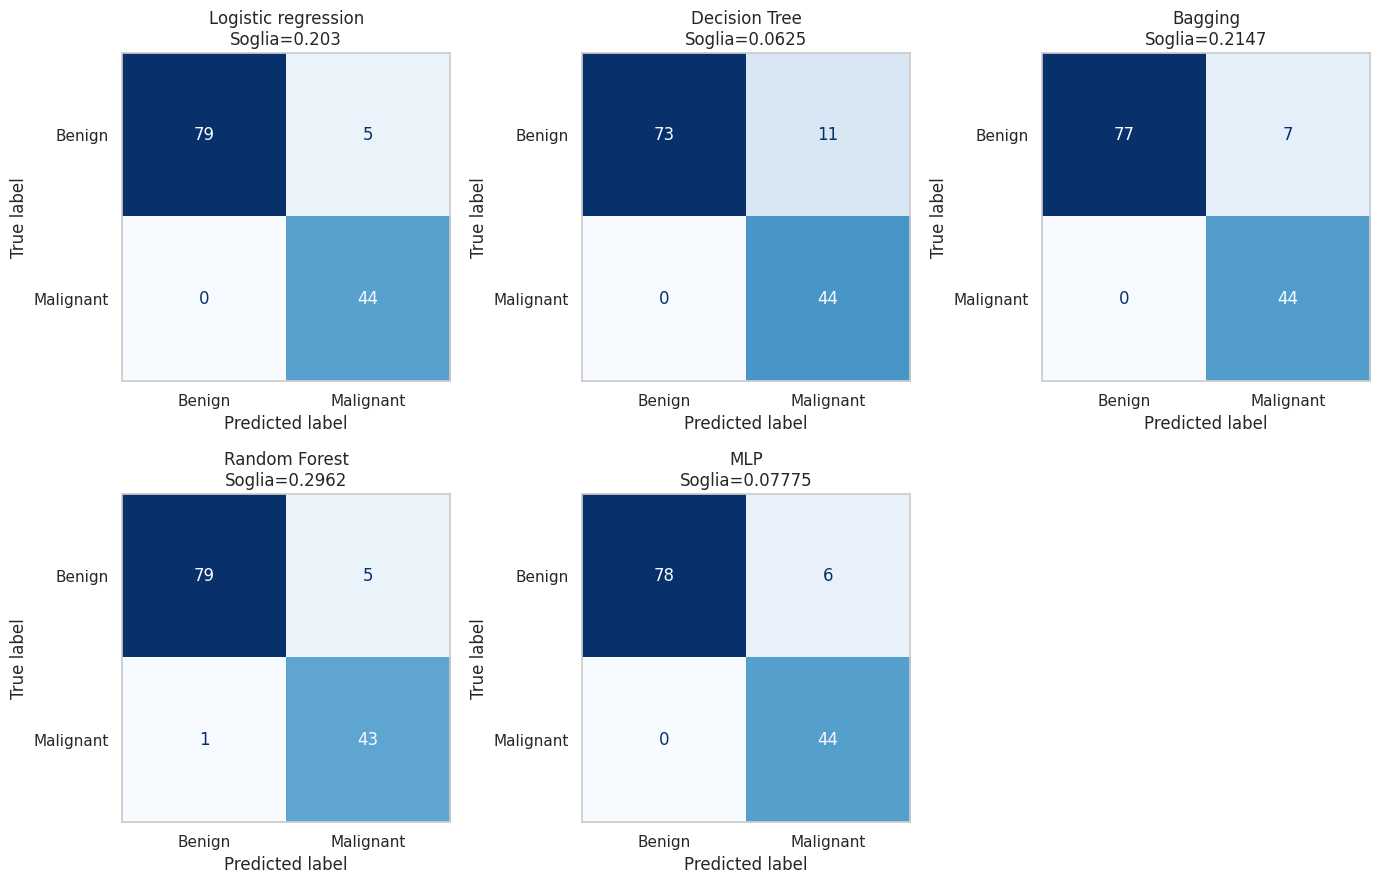

In [19]:
comparison_names = [name for name in test_probabilities if name != "Dummy"]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, name in zip(axes.flat, comparison_names):
    threshold = selected_thresholds[name]
    cm = confusion_matrix(y_test, test_probabilities[name] >= threshold, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{name}\nSoglia={threshold:.4g}")
    ax.grid(False)
for ax in list(axes.flat)[len(comparison_names):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


### ROC e precision–recall

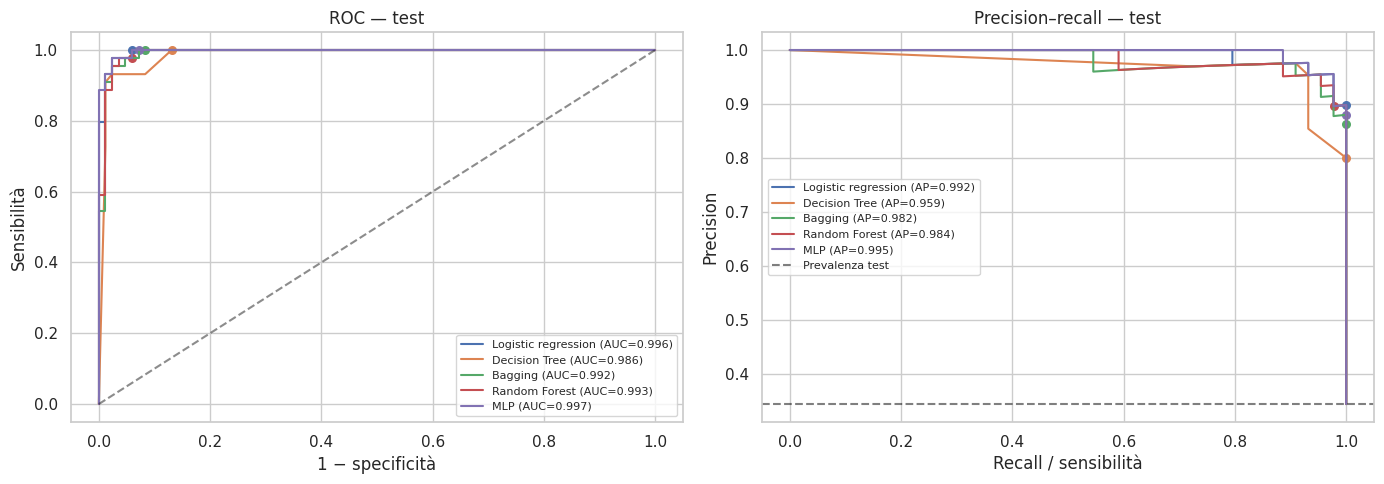

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in comparison_names:
    p = test_probabilities[name]
    metrics = evaluate_probabilities(y_test, p, selected_thresholds[name])
    fpr, tpr, _ = roc_curve(y_test, p)
    precision, recall, _ = precision_recall_curve(y_test, p)
    line, = axes[0].plot(fpr, tpr, label=f"{name} (AUC={metrics['ROC-AUC']:.3f})")
    axes[0].scatter(1 - metrics["Specificity"], metrics["Sensitivity"], color=line.get_color(), s=30)
    line, = axes[1].plot(recall, precision, label=f"{name} (AP={metrics['AP']:.3f})")
    axes[1].scatter(metrics["Sensitivity"], metrics["Precision"], color=line.get_color(), s=30)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].axhline(y_test.mean(), color="black", linestyle="--", alpha=0.5, label="Prevalenza test")
axes[0].set(xlabel="1 − specificità", ylabel="Sensibilità", title="ROC — test")
axes[1].set(xlabel="Recall / sensibilità", ylabel="Precision", title="Precision–recall — test")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 12. Scelta finale

In [21]:
principal_name = locked_protocol["selected_family"]
principal_metrics = evaluate_probabilities(
    y_test, test_probabilities[principal_name], selected_thresholds[principal_name]
)
print(f"Modello selezionato sullo sviluppo: {principal_name}")
print(f"Test: {len(y_test)} osservazioni, {groups_test.nunique()} ID distinti.")
print(f"Maligni riconosciuti: {principal_metrics['TP']} su {int(y_test.sum())}.")
print(f"Falsi negativi: {principal_metrics['FN']}; falsi positivi: {principal_metrics['FP']}.")
print(f"Sensibilità: {principal_metrics['Sensitivity']:.2%}; specificità: {principal_metrics['Specificity']:.2%}.")
print(f"Accuracy: {principal_metrics['Accuracy']:.2%}; precision: {principal_metrics['Precision']:.2%}.")
print(f"ROC-AUC: {principal_metrics['ROC-AUC']:.4f}; AP: {principal_metrics['AP']:.4f}.")
print("Il vincolo di sensibilità era di sviluppo e non è garantito sul test.")
print("Non si conclude superiorità statistica da piccole differenze tra medie.")


Modello selezionato sullo sviluppo: Logistic regression
Test: 128 osservazioni, 125 ID distinti.
Maligni riconosciuti: 44 su 44.
Falsi negativi: 0; falsi positivi: 5.
Sensibilità: 100.00%; specificità: 94.05%.
Accuracy: 96.09%; precision: 89.80%.
ROC-AUC: 0.9959; AP: 0.9922.
Il vincolo di sensibilità era di sviluppo e non è garantito sul test.
Non si conclude superiorità statistica da piccole differenze tra medie.
